# Gaussian solutions

In this notebook the steady state of the Fokker-Planck equation is:

$u = \alpha e^{\beta V\left(\left\|x\right\|^2\right)}$

The used equations are:

- SDE: $ dX_t = \left(-\nabla_x V\left(\left\|X_t\right\|^2\right) + RX_t\right)dt + \sigma dW_t $
- Fokker-Planck: $ u_t = - \sum_i \left(\left(-\nabla_x V\left(\left\|x\right\|^2\right) + Rx\right)_i u\right)_{x_i} + \sigma^2\frac12\sum_{ij} u_{x_ix_j} $

where $R$ is an antisymmetric matrix and $\sigma$ is a constant.

**proof**

We can prove that:

$ u_t = - \sum_i \left(u f_i\right)_{x_i} + \frac12\sum_{ij} {u\Sigma_{ij}}_{x_ix_j} = \left[u, \nabla_x u, \frac12\nabla_x^2 u\right]\cdot\left[\frac12\nabla_x^2\cdot\Sigma-\nabla_x\cdot f, \nabla_x\cdot\Sigma-f, \Sigma\right]$

In this context:
- $\nabla_x V\left(\left\|x\right\|^2\right) = 2V'\left(\left\|x\right\|^2\right)x $ 
- $\nabla_x^2 V\left(\left\|x\right\|^2\right) = 4V''\left(\left\|x\right\|^2\right)xx^T + 2V'\left(\left\|x\right\|^2\right)\text{Id} $
- $\nabla_x u = \nabla_x \alpha e^{\beta V\left(\left\|x\right\|^2\right)} = \beta \nabla_x V\left(\left\|x\right\|^2\right) u = 2 \beta u V'\left(\left\|x\right\|^2\right)x $
- $\nabla_x^2 u = \nabla_x \beta \nabla_x V\left(\left\|x\right\|^2\right) u = \beta u \left[\nabla_x^2 V\left(\left\|x\right\|^2\right) + \beta \nabla_x V\left(\left\|x\right\|^2\right)\nabla_x V\left(\left\|x\right\|^2\right)^T \right] = \beta u \left[4V''\left(\left\|x\right\|^2\right)xx^T + 2V'\left(\left\|x\right\|^2\right)\text{Id} + 4 \beta V'\left(\left\|x\right\|^2\right)^2xx^T \right] $
- $\left[\frac12\nabla_x^2\cdot\Sigma-\nabla_x\cdot f, \nabla_x\cdot\Sigma-f, \Sigma\right] = \left[-\nabla_x\cdot f, -f, \Sigma\right] = \left[\Delta_x V\left(\left\|x\right\|^2\right), \nabla_x V\left(\left\|x\right\|^2\right) - Rx, \sigma^2\text{Id}\right] = \left[4 V''\left(\left\|x\right\|^2\right)\left\|x\right\|^2 + 2dV'\left(\left\|x\right\|^2\right), 2V'\left(\left\|x\right\|^2\right)x - Rx, \sigma^2\text{Id}\right] $
- $ \left(2V'\left(\left\|x\right\|^2\right)x - Rx\right) \cdot 2 \beta u V'\left(\left\|x\right\|^2\right)x = 4\beta u V'\left(\left\|x\right\|^2\right)^2\left\|x\right\|^2 $
- $ \sigma^2\text{Id}\cdot\frac{\beta}{2} u \left[4V''\left(\left\|x\right\|^2\right)xx^T + 2V'\left(\left\|x\right\|^2\right)\text{Id} + 4 \beta V'\left(\left\|x\right\|^2\right)^2xx^T \right] = 4\beta\frac{\sigma^2}{2} u V''\left(\left\|x\right\|^2\right)\left\|x\right\|^2 + 2d\beta\frac{\sigma^2}{2} u V'\left(\left\|x\right\|^2\right) + 4 \beta^2\frac{\sigma^2}{2} u V'\left(\left\|x\right\|^2\right)^2\left\|x\right\|^2 $

So:

$ u_t = \left[u, \nabla_x u, \frac12\nabla_x^2 u\right]\cdot\left[\frac12\nabla_x^2\cdot\Sigma-\nabla_x\cdot f, \nabla_x\cdot\Sigma-f, \Sigma\right] = 4 u V''\left(\left\|x\right\|^2\right)\left\|x\right\|^2 + 2duV'\left(\left\|x\right\|^2\right) + 4\beta u V'\left(\left\|x\right\|^2\right)^2\left\|x\right\|^2 + 4\beta\frac{\sigma^2}{2} u V''\left(\left\|x\right\|^2\right)\left\|x\right\|^2 + 2d\beta\frac{\sigma^2}{2} u V'\left(\left\|x\right\|^2\right) + 4 \beta^2\frac{\sigma^2}{2} u V'\left(\left\|x\right\|^2\right)^2\left\|x\right\|^2 $

$ = u\left[4\left\|x\right\|^2\left(\beta V'\left(\left\|x\right\|^2\right)^2+V''\left(\left\|x\right\|^2\right)\right) + 2dV'\left(\left\|x\right\|^2\right)\right]\left(1+\beta\frac{\sigma^2}{2}\right) $


If $\frac{\beta\sigma^2}{2}=-1$ we have the thesis.

## Training

We want a neural network with parameters $\theta$ representd by $x\mapsto\tilde{u}(x,\theta)$ such that minimizes:

$$L(\theta) = \frac{1}{N^X}\sum_{i=1}^{N^X}(\mathcal{L}\tilde{u}(x_i,\theta))^2+\frac{1}{N^Y}\sum_{j=1}^{N^Y}(\tilde{u}(y_j,\theta)-v(y_j))^2:=L_1(\theta)+L_2(\theta)$$

where:
- $\theta$ is the set of parameters of the NN
- $x_i\in\mathbb{R}^n$ with $i=1,2,\ldots,N^X$
- $y_j\in\mathbb{R}^n$ with $j=1,2,\dots,N^Y$
- $v(y_j)$ is the solution of the MC approximation.

## Monte Carlo

Here we implement the function $v$, in the paper the authors report the procedure:

- A single trajectory for Euler-Maruyama numerical scheme with:
    - $10^7$ steps
    - the time step size is 0.001
    - empirical probability on a $200\times200$ mesh of the region $D = [−2,2] ×[−2,2]$
    - sampling from this trajectory 

In [1]:
# monte carlo implementation of the example in Zhai et al. (2022)
import torch
from zhai2022.sde import Model
from zhai2022.sde.euler_maruyama import EulerMaruyama

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

R = torch.tensor([[0.0,1.0],[-1.0,0.0]], dtype=torch.float64, device=device)

# Define drift, diffusion, and initial state functions
def drift(X, _t):
    return - 4 * (torch.norm(X, dim=-1, keepdim=True)**2-1) * X + torch.einsum('ij, sj -> si', R, X)

def diffusion(X, _t):
    return torch.tile(torch.eye(X.shape[1], dtype=torch.float64, device=device), (X.shape[0], 1, 1))

def initial_state(n_samples):
    return torch.zeros((n_samples, 2), dtype=torch.float64, device=device)

# Create a Model instance
model = Model(drift, diffusion, initial_state, initial_time=0.0, n_dim=2)

# burn-in: 10sec of real time simulation
dt_schedule = torch.ones(int(10/0.001), dtype=torch.float64, device=device) * 0.001
euler_maruyama = EulerMaruyama(model, dt_schedule)
X = euler_maruyama.get_end(n_samples=1000)  # shape: (1000, 2)

# start simulation for 10^7 samples
dt_schedule = torch.ones(10**4, dtype=torch.float64, device=device) * 0.001
def new_init(n_samples):
    return X[torch.randint(0, X.shape[0], (n_samples,), device=device)]
model = Model(drift, diffusion, new_init, initial_time=0.0, n_dim=2)
euler_maruyama = EulerMaruyama(model, dt_schedule)
Xtrj = euler_maruyama.get_trajectory(n_samples=1000)  # shape: (n_time_steps, 1000, n_dim)

The idea is simple:

after a burn-in (in this case with 10sec of real time simulation and starting point in $0$), the authors make a single trajectory with many steps and a long time. Although there is a dependency between one sample and the next, the union of all samples from a long real time (10^4 seconds) trajectory allows us to no longer recognize the trajectory and have samples of the final distribution.

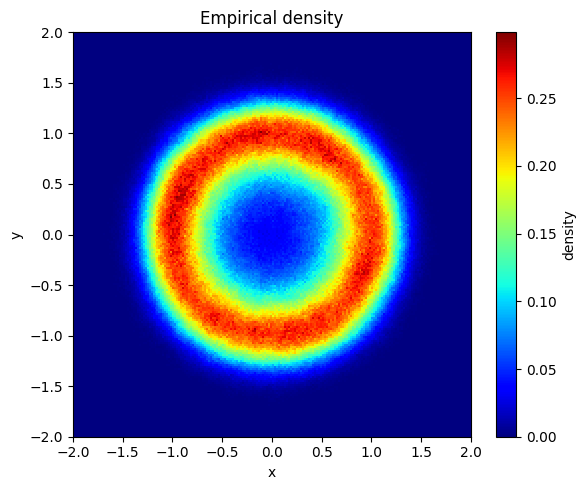

In [2]:
# see density
from matplotlib import pyplot as plt
import numpy as np

np_Xtrj = Xtrj.cpu().numpy()

# compute empirical density
x = np_Xtrj[:,:,0].reshape(-1)
y = np_Xtrj[:,:,1].reshape(-1)

# dominio e griglia
xmin, xmax = -2, 2
ymin, ymax = -2, 2
nx, ny = 200, 200   # come il paper

plt.figure(figsize=(6, 5))
counts, xedges, yedges, img = plt.hist2d(
    x, y,
    bins=[nx, ny],
    range=[[xmin, xmax], [ymin, ymax]],
    density=True,        # normalizza: somma ≈ 1
    cmap="jet",
    cmin=0,
)
plt.colorbar(label="density")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Empirical density")
plt.tight_layout()
plt.show()

In [3]:
def v(vec: np.ndarray):
    # vec has shape N,2
    mask = np.logical_and(
        np.logical_and(vec[:,0]>=xmin, vec[:,0]<xmax),
        np.logical_and(vec[:,1]>=ymin, vec[:,1]<ymax)
    )
    valid_vec = vec[mask]
    ix = np.searchsorted(xedges, valid_vec[:,0], side="right") - 1
    iy = np.searchsorted(yedges, valid_vec[:,1], side="right") - 1

    values = np.empty(vec.shape[0])

    values[mask] = counts[ix,iy]
    values[~mask] = 0.0

    return values

## Physics Information

Here, we compute $\mathcal{L}u$ for a Gaussian steady state.

The authors use $V(r^2) = (r^2-1)^2$

In [4]:
from zhai2022.fokker_planck import Gaussian
import torch

FP_model = Gaussian(
    potential=lambda r2: (r2 - 1)**2,
    rotational_matrix=lambda x: torch.stack([
        torch.stack([torch.zeros(x.shape[0]), torch.ones(x.shape[0])], dim=-1),
        torch.stack([-torch.ones(x.shape[0]), torch.zeros(x.shape[0])], dim=-1),
    ], dim=-2),
    sigma=2.0,
    d_U=lambda r2: 2.0 * (r2 - 1), d2_U=lambda r2: 2.0 * torch.ones_like(r2),
)

## Neural Network model
The authors used an MLP defined as follow:

In [5]:
# creo una MLP
from torch import nn

class MLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.Tanh(),
            nn.Linear(16, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 16),
            nn.Tanh(),
            nn.Linear(16, 4),
            nn.Tanh(),
            nn.Linear(4, output_dim),
        )

    def forward(self, x: torch.tensor) -> torch.tensor:
        return self.network(x)

We can compute the derivative respect the input until the second derivative

In [6]:
NN_model = MLP(input_dim=2, output_dim=1)

# example input
x = torch.tensor([[0.5, 0.5], [1.0, 0.0], [0.0, -1.0]], requires_grad=True)

FP_model.u_t(
    lambda x,_t: NN_model(x).squeeze(-1),
    x,
    0.0,
)

tensor([-0.0120, -1.3685, -1.3052], grad_fn=<AddBackward0>)